<a href="https://colab.research.google.com/github/abyansyah052/NLP-1/blob/main/Week2%263_Assignment/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TUGAS 2 — EDA**

In [15]:
!pip install pandas matplotlib seaborn nltk wordcloud -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string
from wordcloud import WordCloud
from nltk.corpus import stopwords

nltk.download('stopwords')

%matplotlib inline
%config InlineBackend.figure_format='retina'
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (15, 10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [43]:
from google_play_scraper import reviews_all, Sort
import pandas as pd

df = pd.read_csv('/content/df_jagorev_processed.csv')

df['content'] = df['content'].apply(
    lambda x: ''.join(str(x).split()) if len(str(x)) > 1 and str(x)[1] == ' ' else str(x)
)
df['tweet_without_stopwords'] = df['tweet_without_stopwords'].apply(
    lambda x: ''.join(str(x).split()) if len(str(x)) > 1 and str(x)[1] == ' ' else str(x)
)

if 'at' not in df.columns:

    raw = reviews_all(
        'com.jago.digitalBanking',
        sleep_milliseconds=0,
        lang='id', country='id',
        sort=Sort.NEWEST,
    )
    df_raw = pd.DataFrame(raw)[['at']].iloc[:len(df)].reset_index(drop=True)
    df['at'] = pd.to_datetime(df_raw['at'])
else:
    df['at'] = pd.to_datetime(df['at'])

print(f"Shape: {df.shape}")
print(f"Sample content: {df['content'].head(3).tolist()}")
df.head()

Scraping ulang untuk ambil tanggal...
Shape: (59965, 8)
Sample content: ['baguz', 'gokil', 'bosok']


,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating,tweet_without_stopwords,wordCount_after_stopwords,at
0,baguz,5,0.0,0.0,Positive,baguz,5,2026-03-30 20:01:48
1,gokil,5,0.0,0.0,Positive,gokil,5,2026-03-30 19:43:00
2,bosok,1,0.0,0.0,Negative,bosok,5,2026-03-30 19:11:58
3,logintolongfixbukaanj,1,0.0,0.0,Negative,logintolongfixbukaanj,21,2026-03-30 18:55:12
4,jlas,1,0.0,0.0,Negative,jlas,4,2026-03-30 18:42:29


In [44]:
df.info()
missing = df.isnull().sum()
print("Missing Values Summary:")
print(missing[missing > 0])
print(f"\nTotal missing: {missing.sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59965 entries, 0 to 59964
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   content                    59965 non-null  object        
 1   score                      59965 non-null  int64         
 2   sentiment_polarity         59965 non-null  float64       
 3   sentiment_subjective       59965 non-null  float64       
 4   sentiment_rating           59965 non-null  object        
 5   tweet_without_stopwords    59965 non-null  object        
 6   wordCount_after_stopwords  59965 non-null  int64         
 7   at                         59965 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 3.7+ MB
Missing Values Summary:
Series([], dtype: int64)

Total missing: 0


/tmp/ipykernel_10595/1936621414.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['score'], palette='viridis')


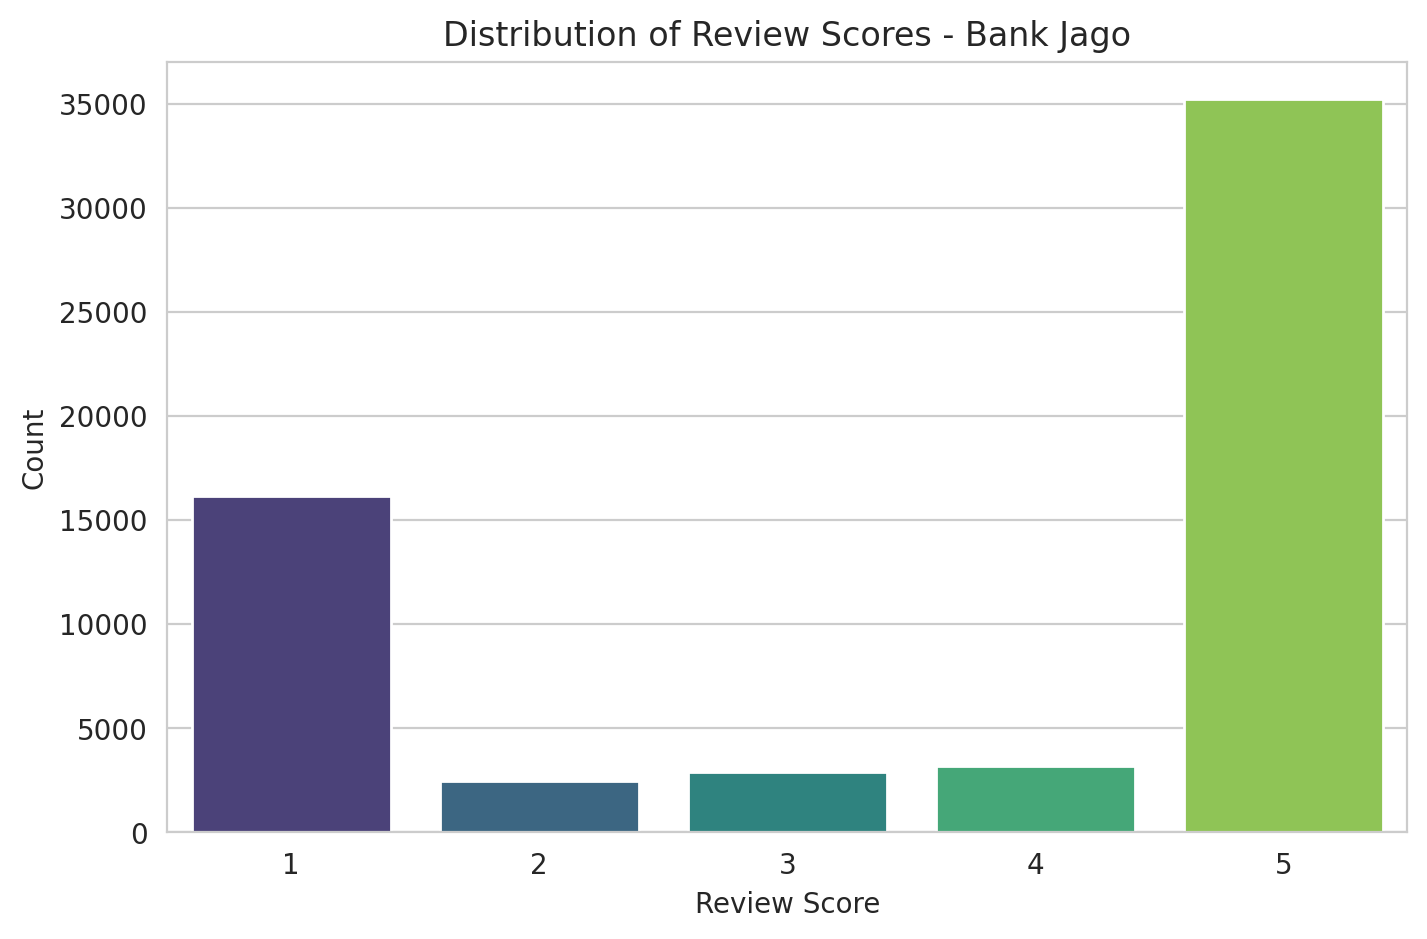

In [45]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df['score'], palette='viridis')
plt.title('Distribution of Review Scores - Bank Jago')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.show()

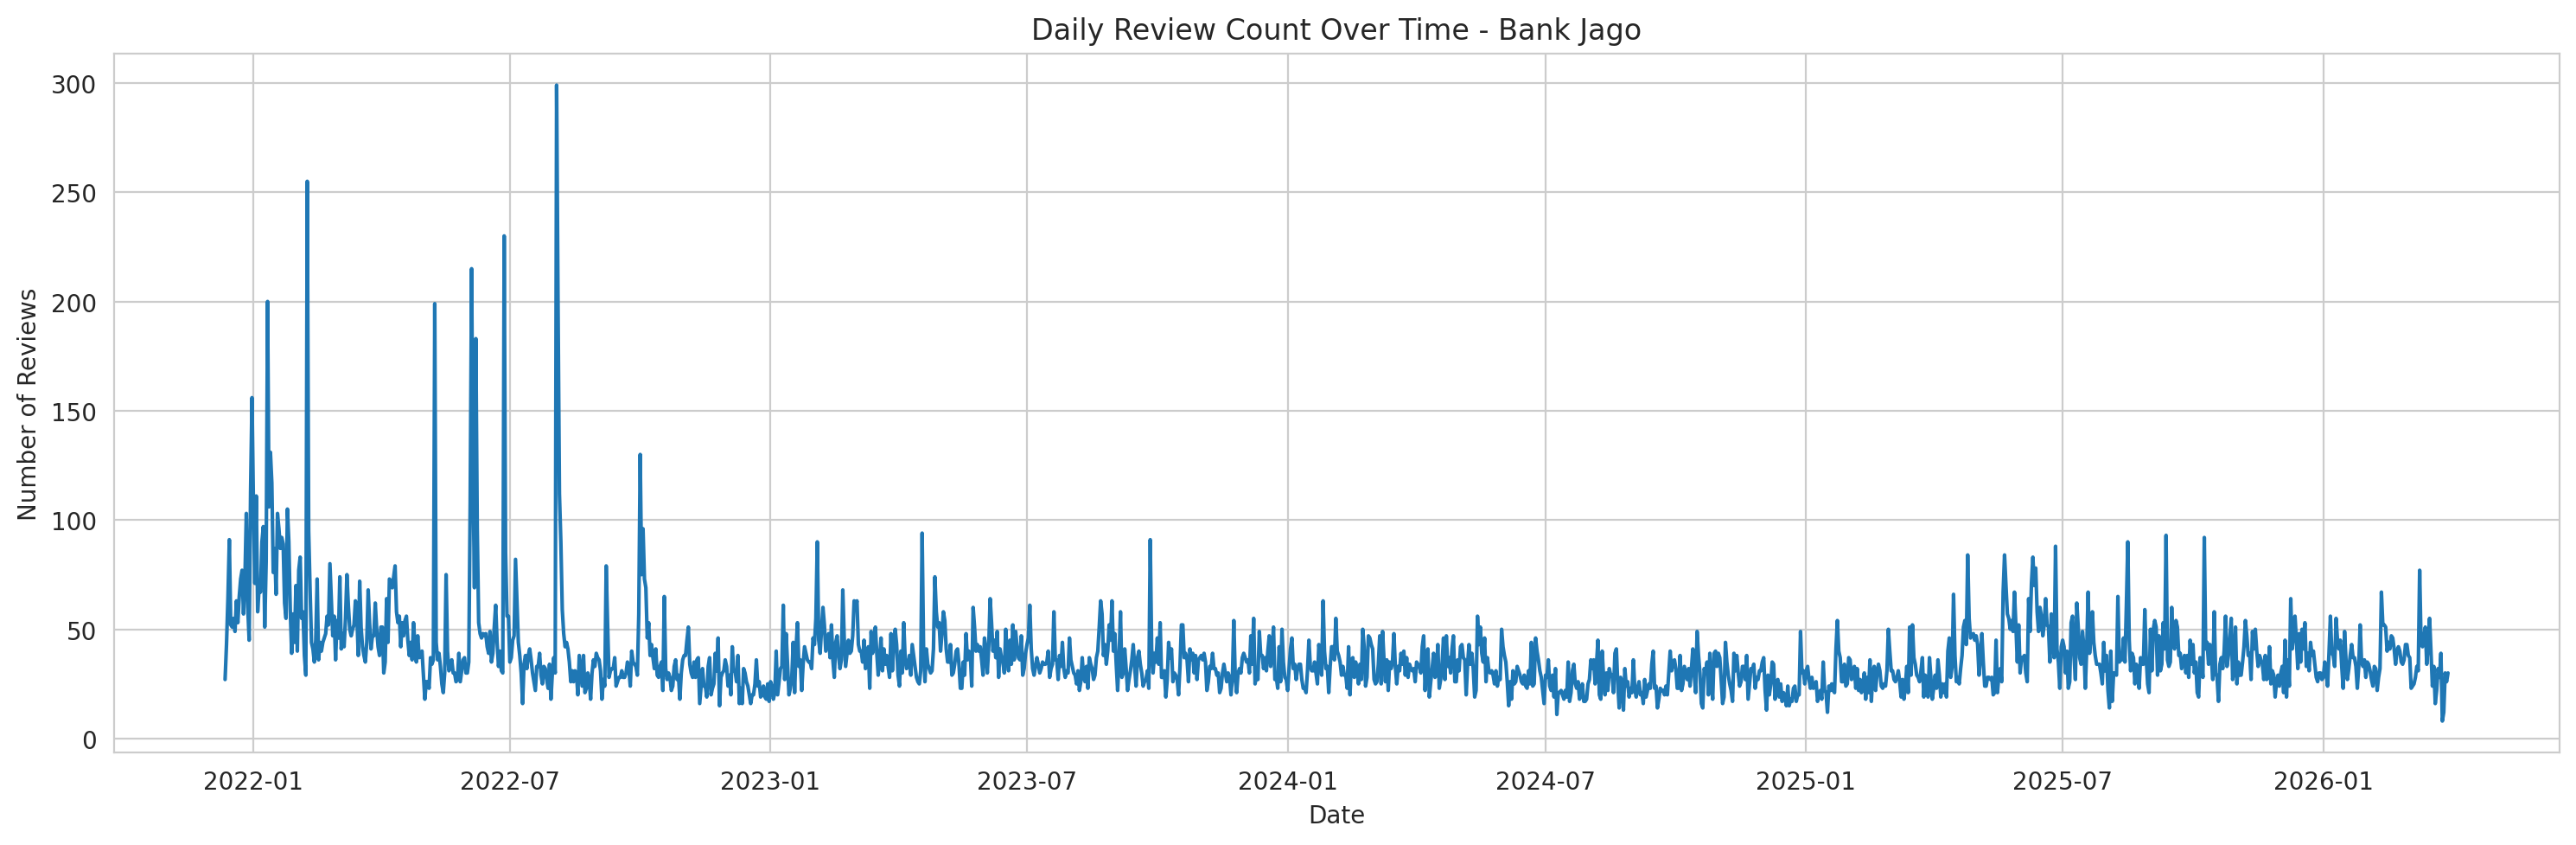

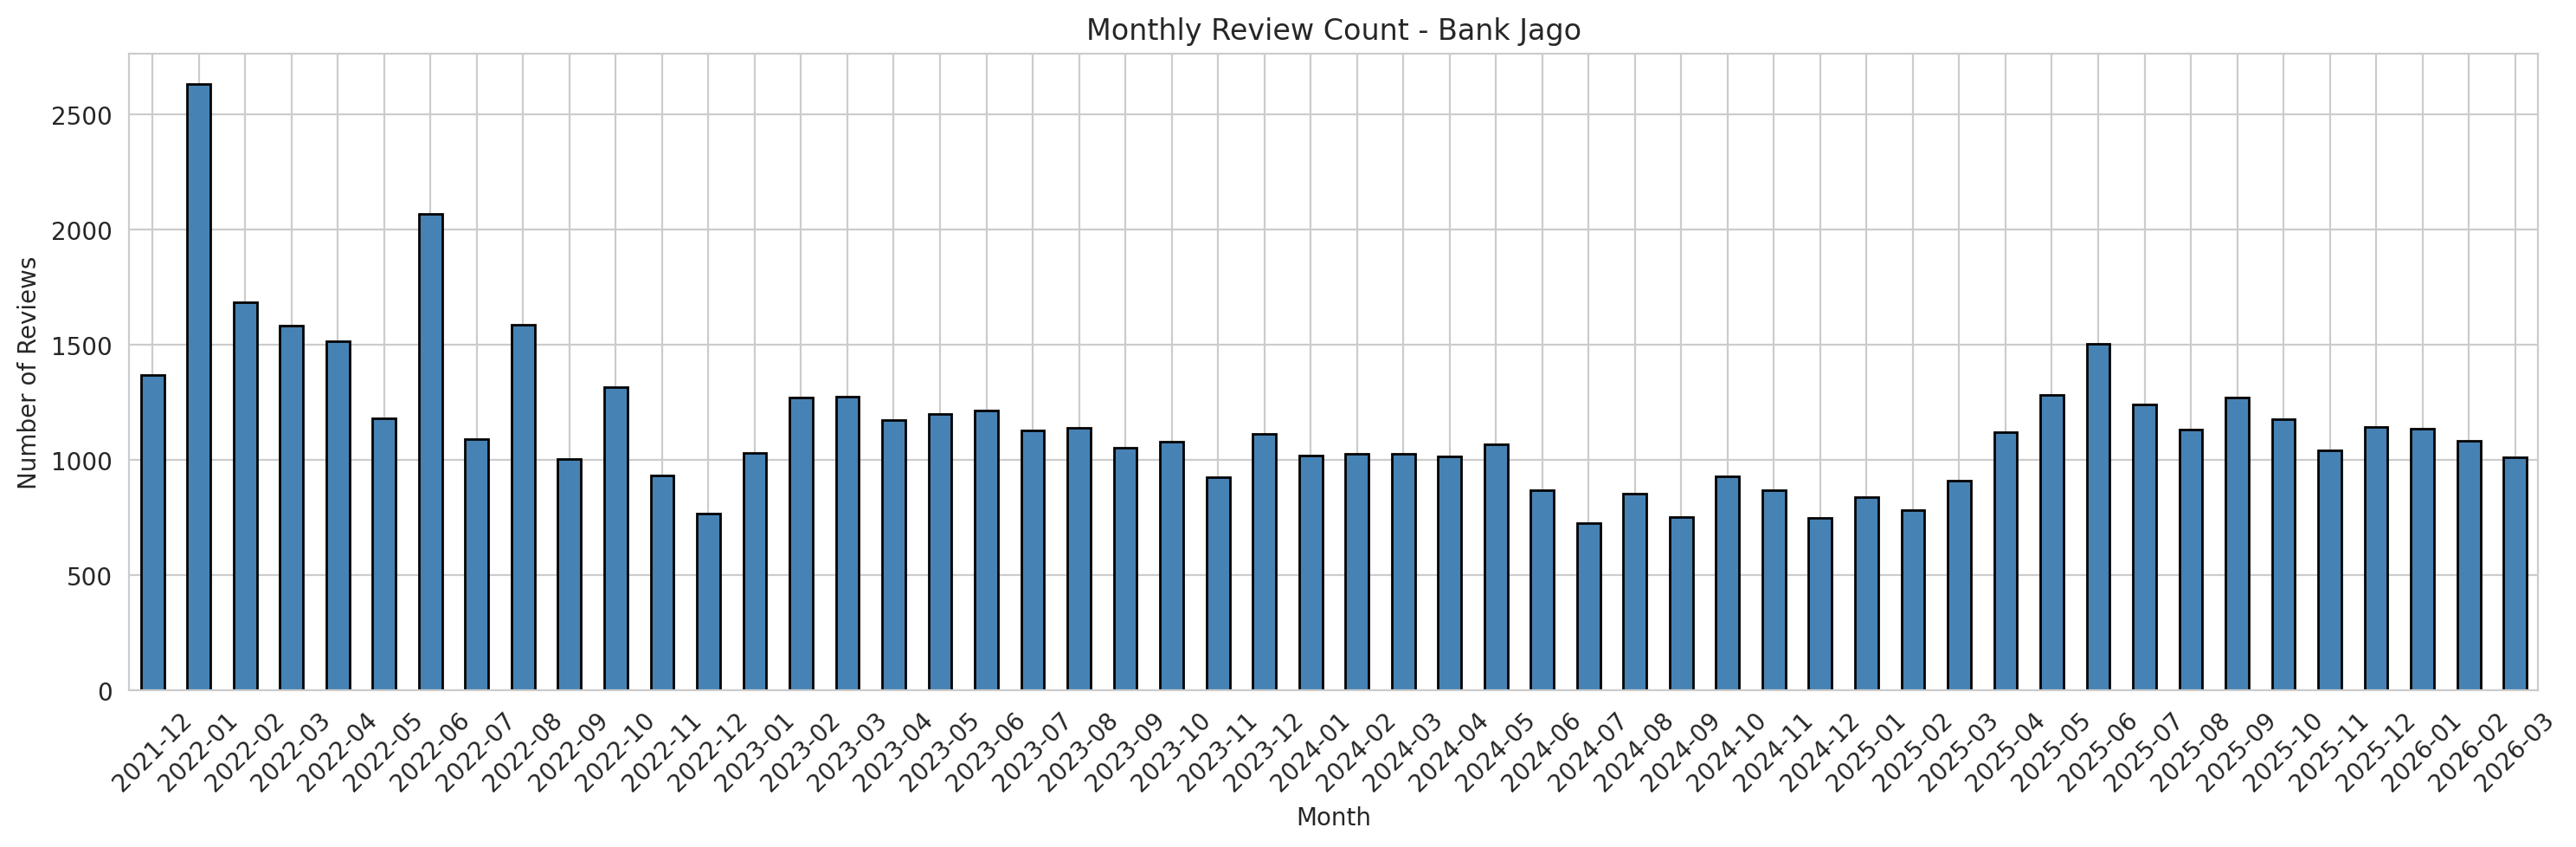

In [46]:
df['review_date'] = df['at'].dt.date
review_trend = df.groupby('review_date').size()

plt.figure(figsize=(15, 5))
review_trend.plot()
plt.title('Daily Review Count Over Time - Bank Jago')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.grid(True)
plt.tight_layout()
plt.show()

df['review_month'] = df['at'].dt.to_period('M')
monthly_trend = df.groupby('review_month').size()

plt.figure(figsize=(15, 5))
monthly_trend.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Monthly Review Count - Bank Jago')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_10595/2079621018.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


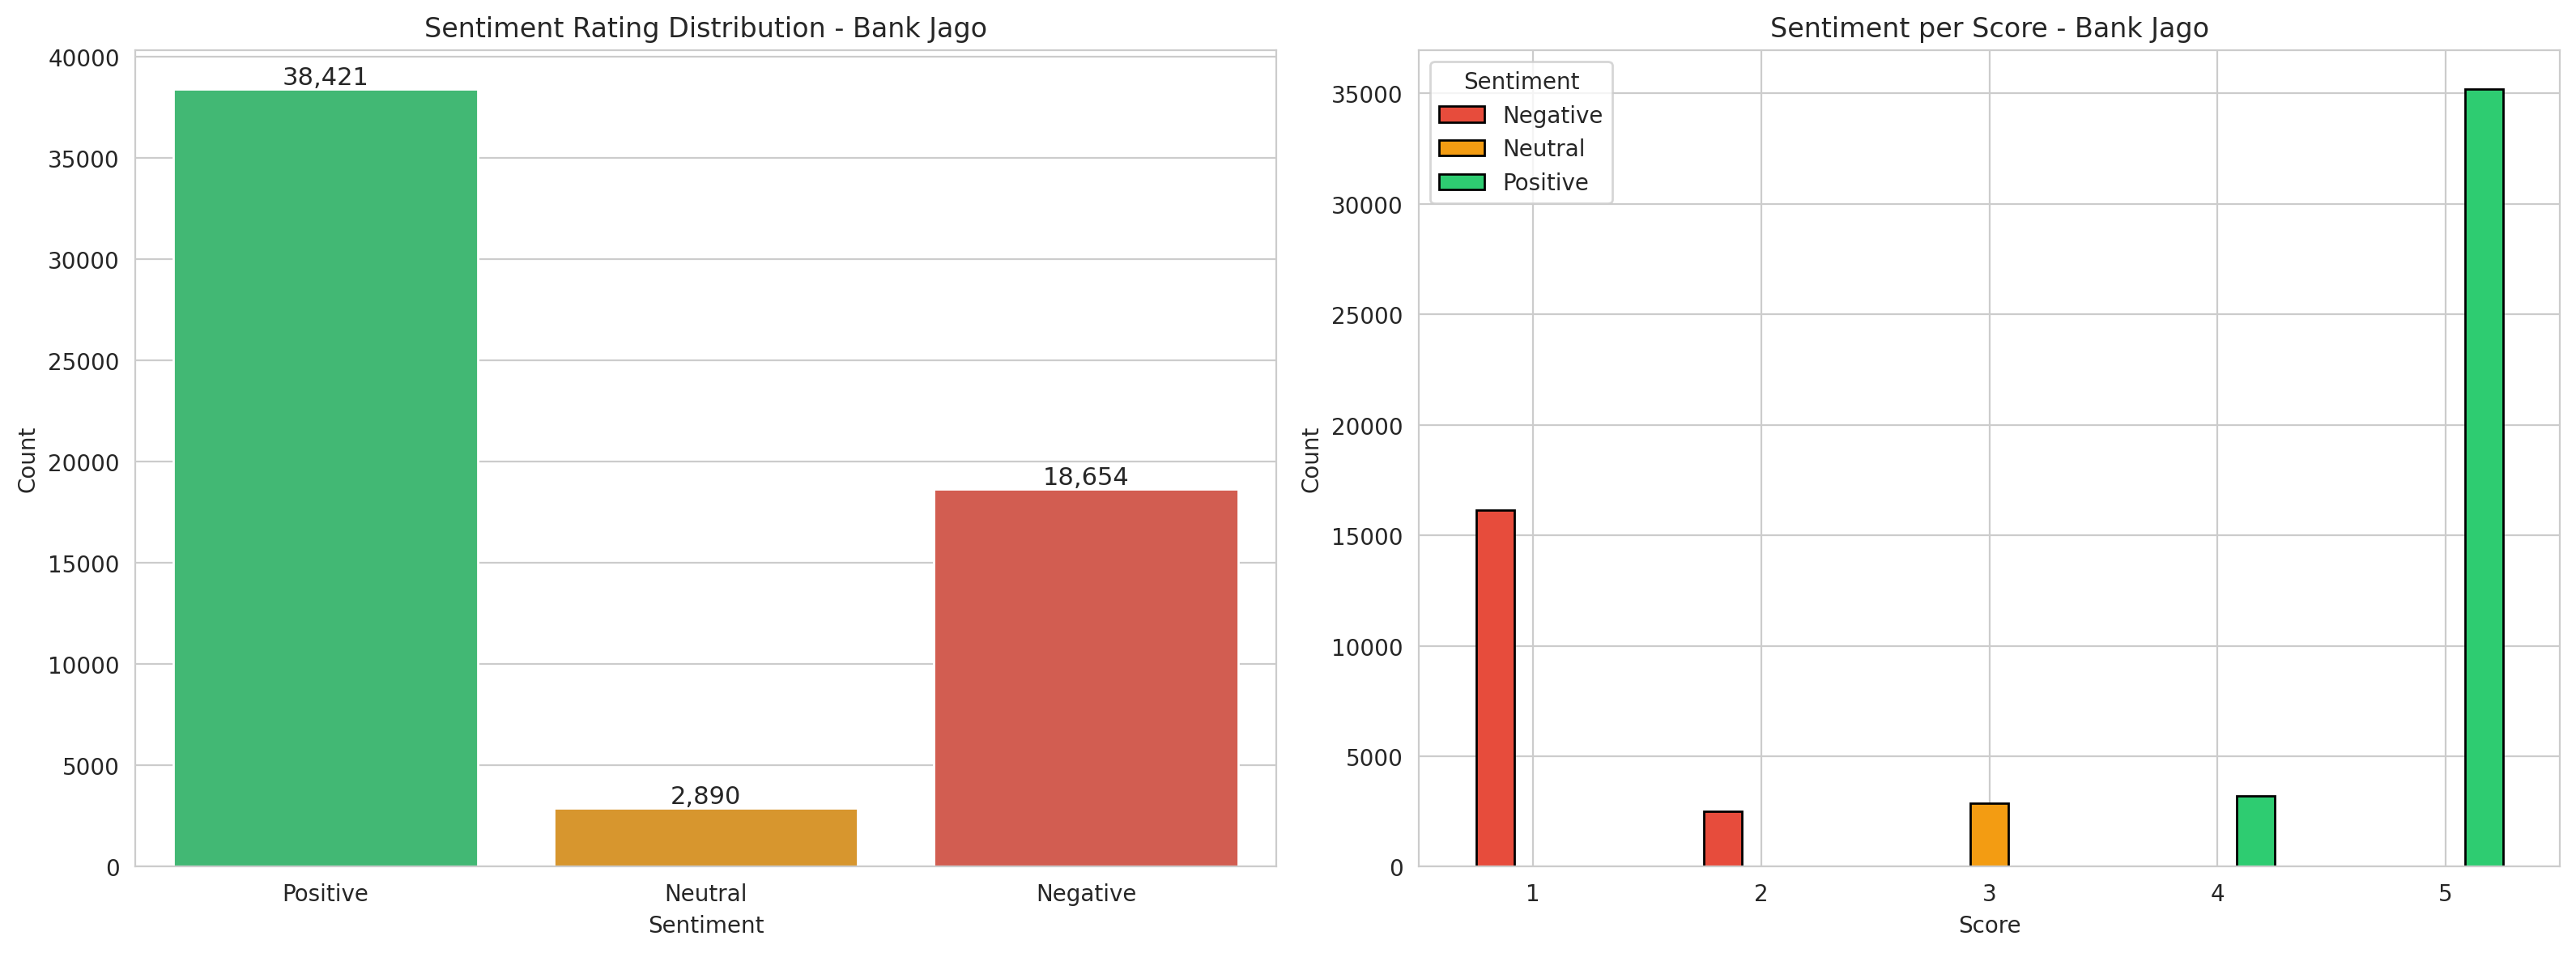

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(
    data=df, x='sentiment_rating',
    order=['Positive', 'Neutral', 'Negative'],
    palette={'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'},
    ax=axes[0]
)
axes[0].set_title('Sentiment Rating Distribution - Bank Jago')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

sentiment_score = df.groupby(['score', 'sentiment_rating']).size().unstack(fill_value=0)
sentiment_score.plot(
    kind='bar',
    color=['#e74c3c', '#f39c12', '#2ecc71'],
    edgecolor='black', ax=axes[1]
)
axes[1].set_title('Sentiment per Score - Bank Jago')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Count')
axes[1].tick_params(rotation=0)
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.show()

kolom: tweet_without_stopwords
Total unique words: 39960
              Word  Frequency
0           mantap       3544
1            bagus       2782
2            bantu        978
3            keren        677
4            mudah        331
5             coba        306
6          manfaat        238
7             puas        229
8             muas        219
9           mantab        212
10     bagusbanget        204
11          banget        198
12          mantul        159
13            suka        156
14             job        132
15          sukses        129
16     terimakasih        122
17         mantapp        118
18  mudahtransaksi        117
19           ribet        115


/tmp/ipykernel_10595/1020528392.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20, x='Word', y='Frequency', palette='Blues_r')


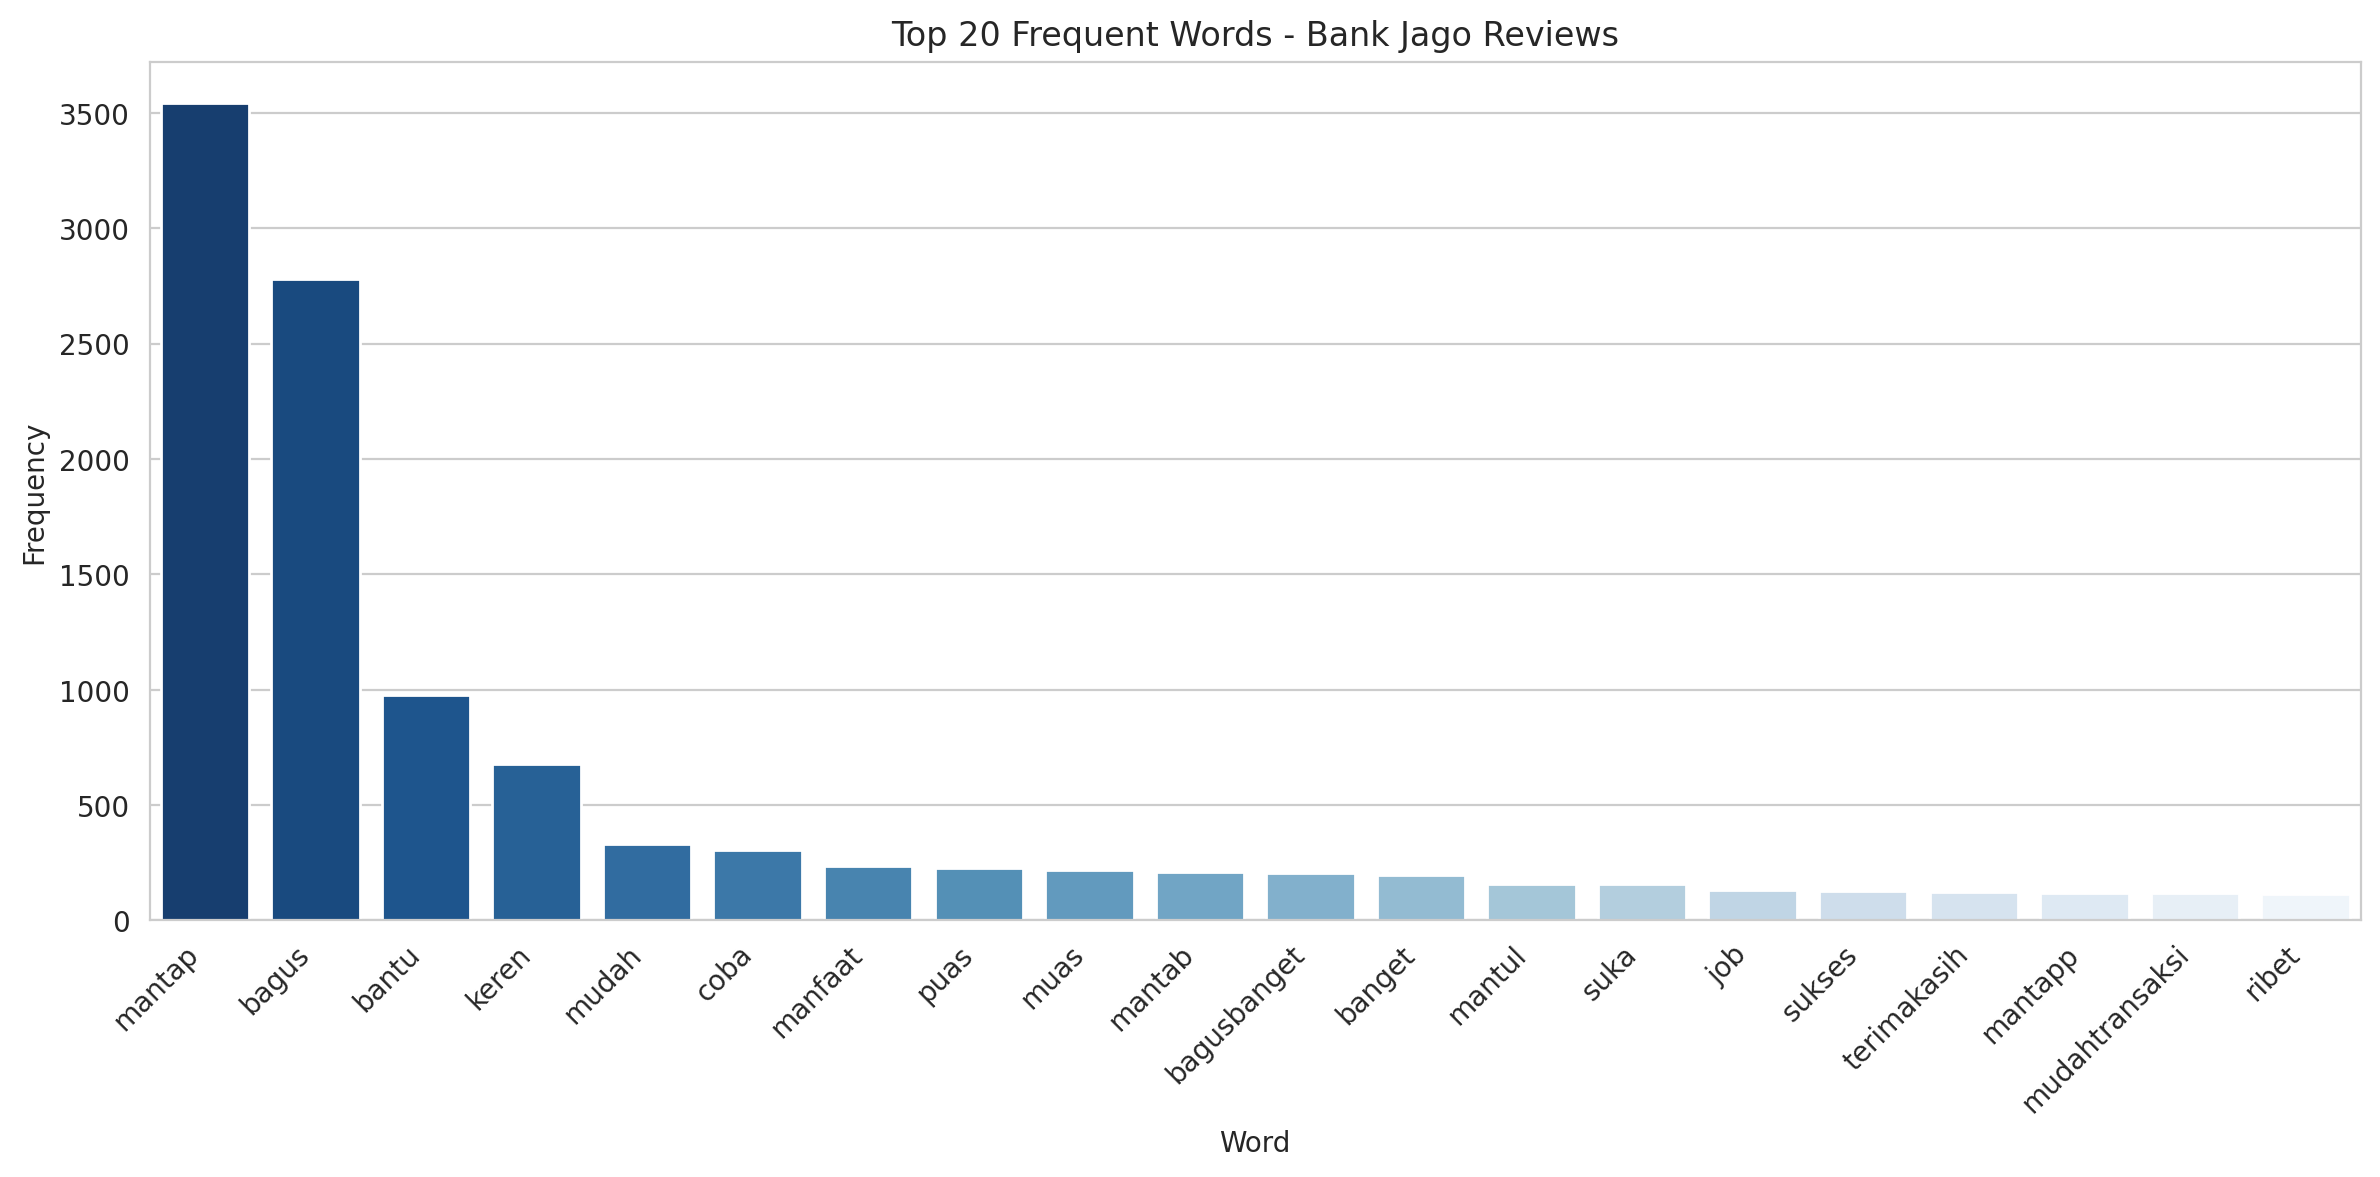

In [48]:
stop_words = set(stopwords.words('indonesian'))

# Pakai tweet_without_stopwords kalau ada isinya, fallback ke content
text_col = 'tweet_without_stopwords' if df['tweet_without_stopwords'].dropna().str.strip().ne('').any() else 'content'
print(f"kolom: {text_col}")

all_text = ' '.join(df[text_col].dropna().astype(str)).lower()
all_text = all_text.translate(str.maketrans('', '', string.punctuation))

words = all_text.split()
filtered_words = [w for w in words if w not in stop_words and len(w) > 1]

word_counts = Counter(filtered_words)
top20 = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

print(f"Total unique words: {len(word_counts)}")
print(top20)

plt.figure(figsize=(12, 6))
sns.barplot(data=top20, x='Word', y='Frequency', palette='Blues_r')
plt.title('Top 20 Frequent Words - Bank Jago Reviews')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

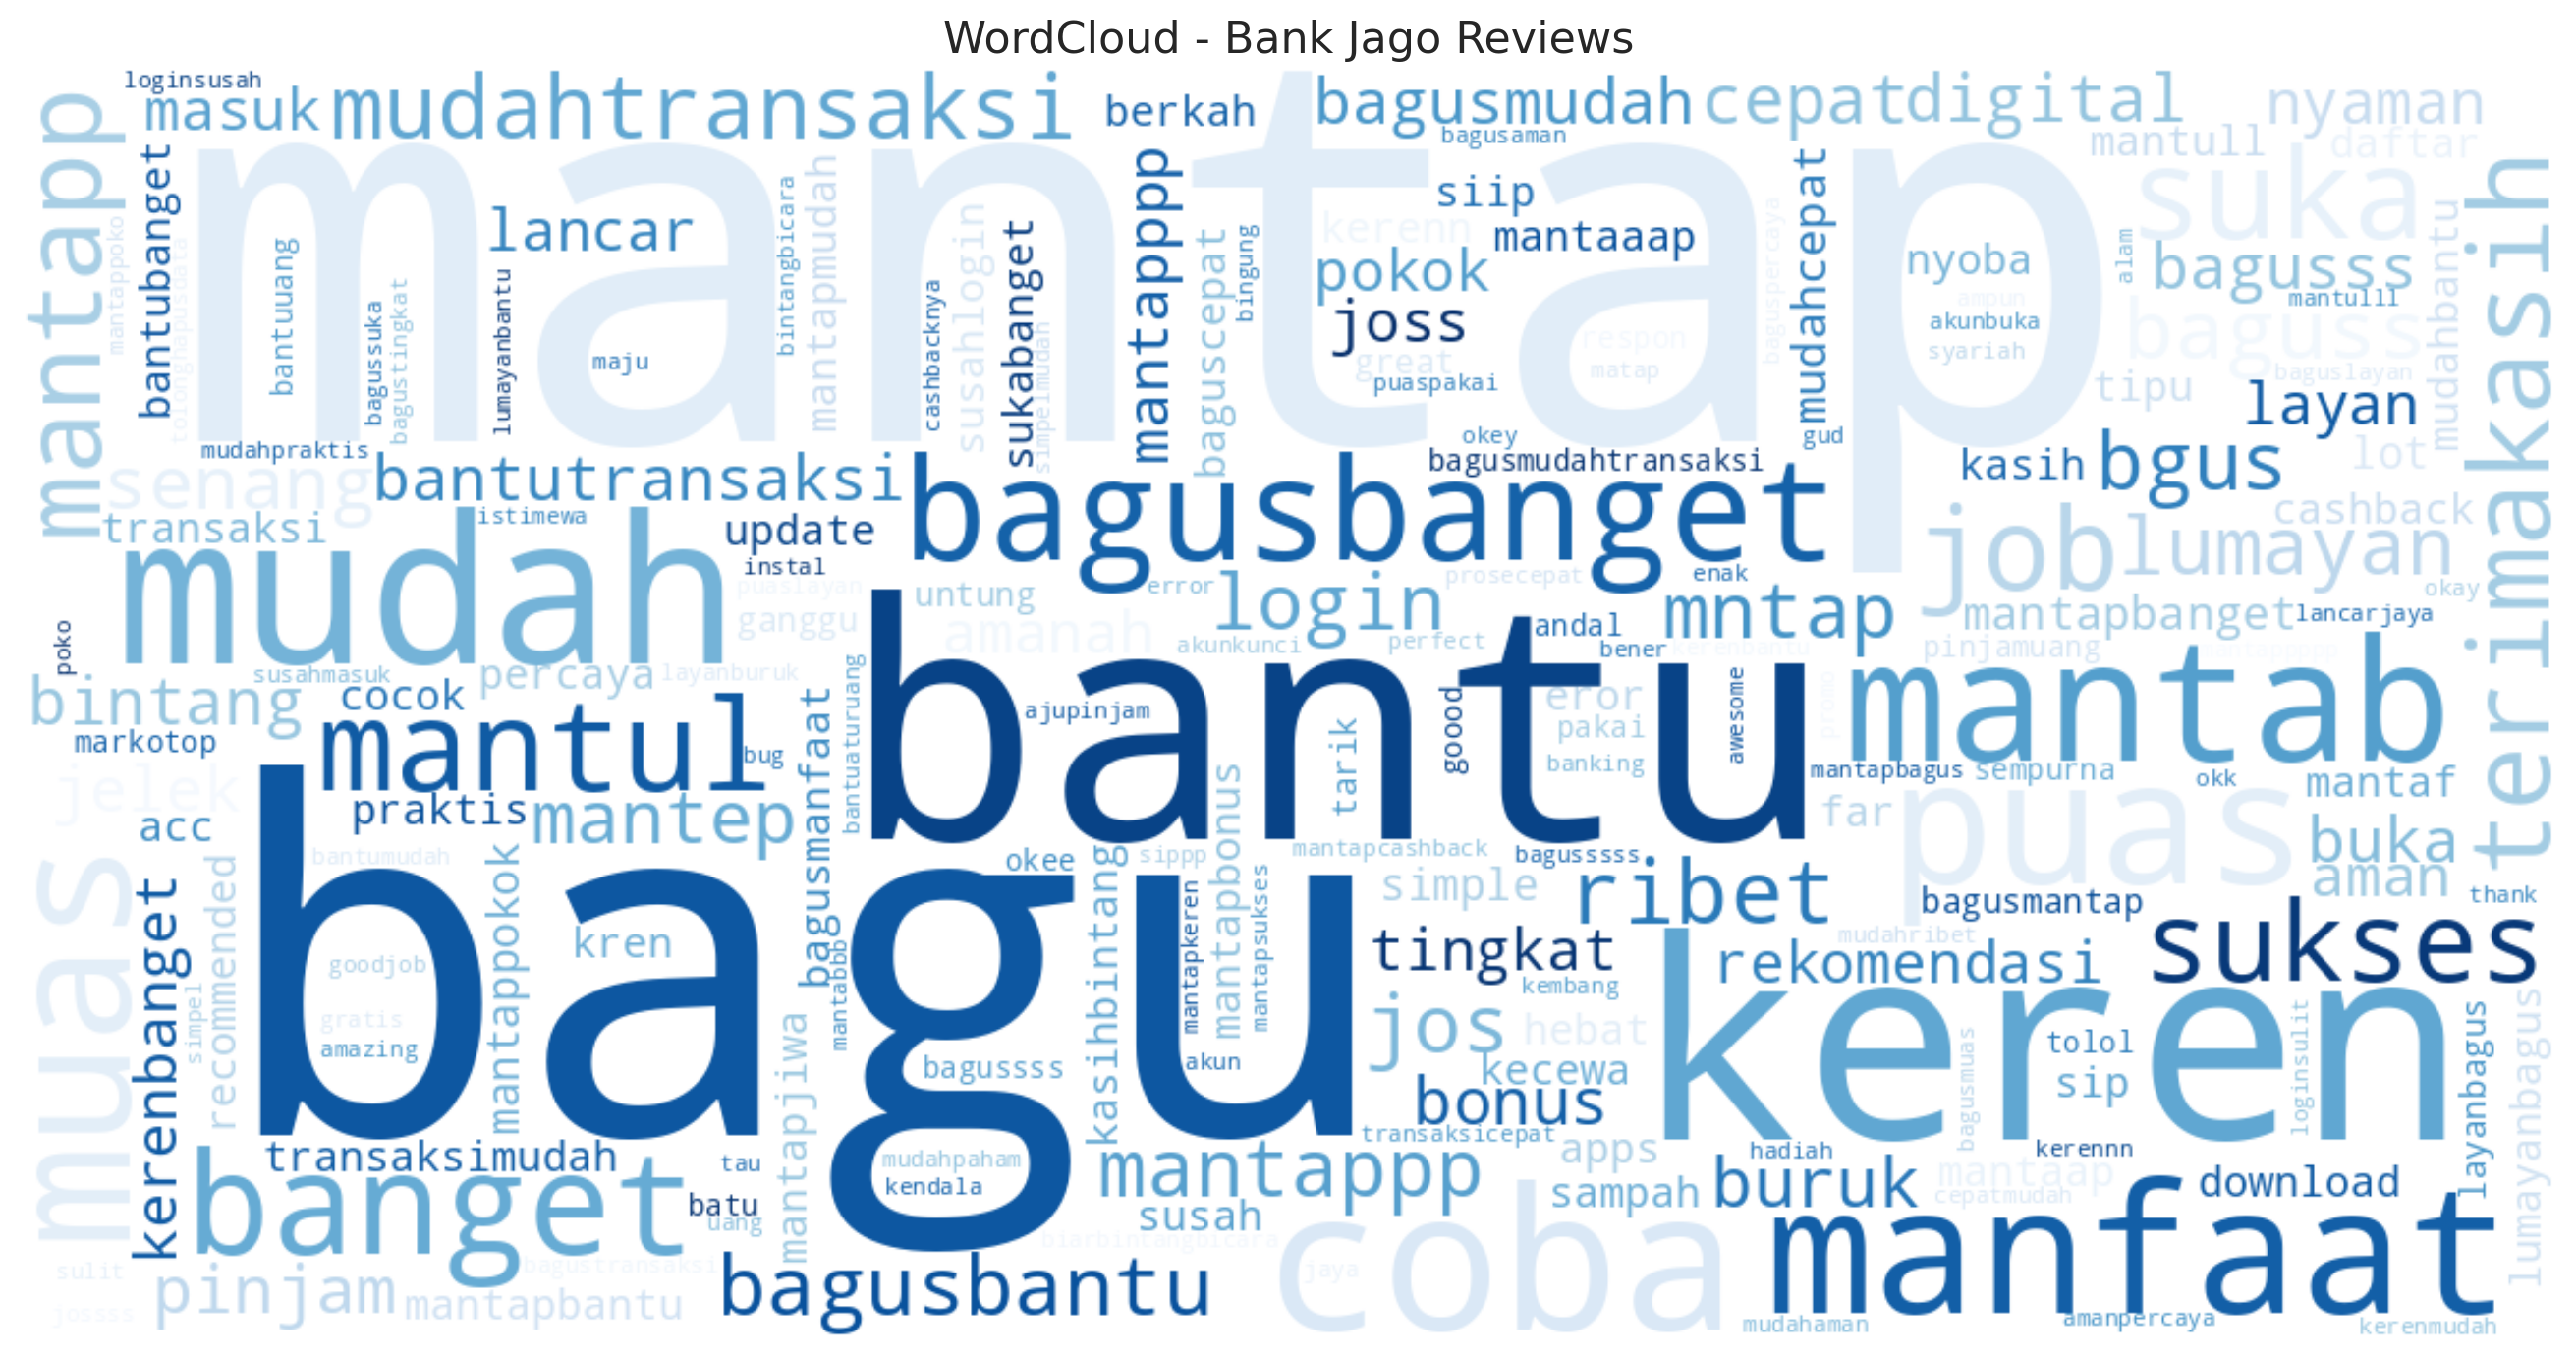

In [49]:
wordcloud_text = ' '.join(filtered_words)

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='Blues',
    max_words=200
).generate(wordcloud_text)

plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Bank Jago Reviews', fontsize=16)
plt.tight_layout()
plt.show()

/tmp/ipykernel_10595/3659332590.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


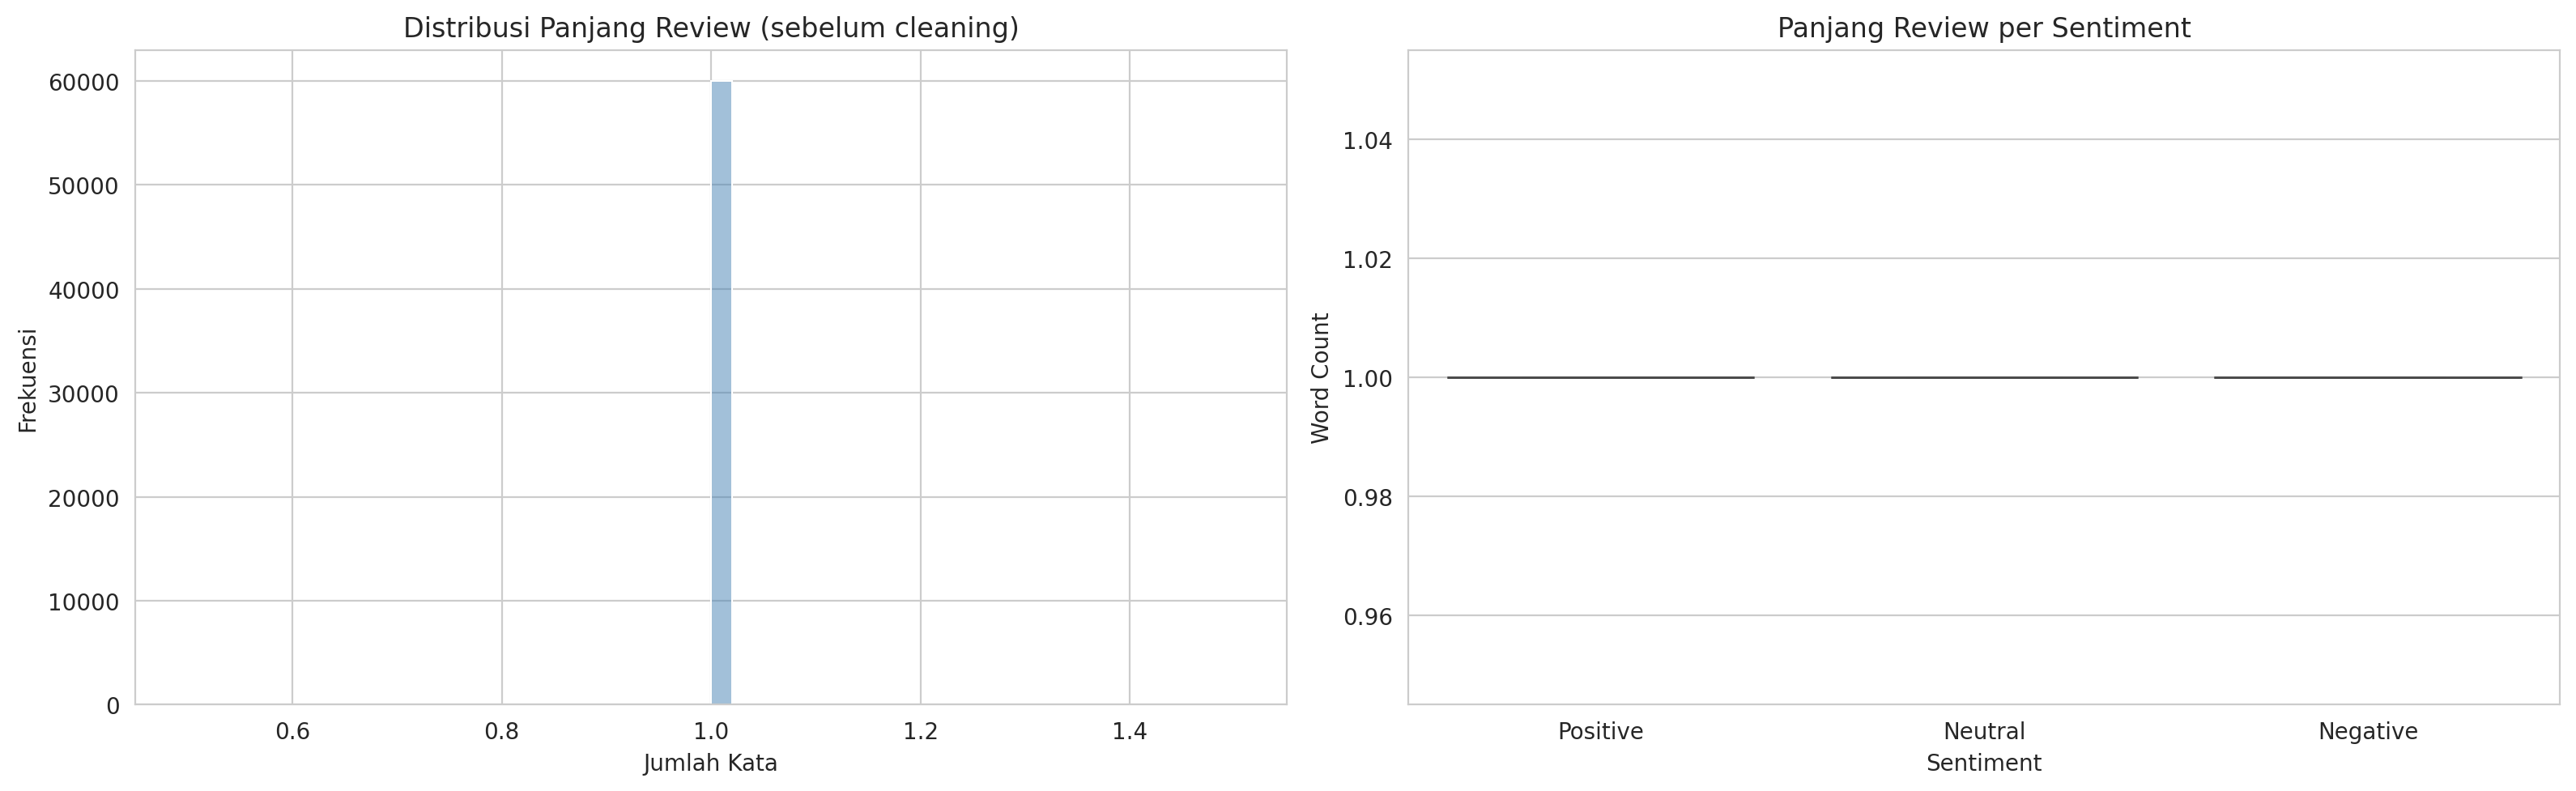

In [53]:

df['wordCount'] = df['content'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['wordCount'], bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribusi Panjang Review (sebelum cleaning)')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')

sns.boxplot(
    data=df, x='sentiment_rating', y='wordCount',
    order=['Positive', 'Neutral', 'Negative'],
    palette={'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'},
    ax=axes[1]
)
axes[1].set_title('Panjang Review per Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.show()

In [54]:
print("Statistik Deskriptif")
df[['score', 'sentiment_polarity', 'sentiment_subjective',
    'wordCount', 'wordCount_after_stopwords']].describe().round(3)

Statistik Deskriptif


,score,sentiment_polarity,sentiment_subjective,wordCount,wordCount_after_stopwords
count,59965.000,59965.000,59965.000,59965.0,59965.000
mean,3.647,0.029,0.041,1.0,28.647
std,1.761,0.141,0.151,0.0,31.570
min,1.000,-1.000,0.000,1.0,2.000
25%,1.000,0.000,0.000,1.0,6.000
50%,5.000,0.000,0.000,1.0,17.000
75%,5.000,0.000,0.000,1.0,37.000
max,5.000,1.000,1.000,1.0,257.000
